## 기본 통계량 및 분포 분석

In [14]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [ ]:
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum()
})
info_df

,Data Type,Non-Null Count,Null Count
Unnamed: 0,int64,22248,0
id,int64,22248,0
name,str,22248,0
description,str,22248,0
host_id,int64,22248,0
host_since,str,22248,0
host_response_time,float64,22248,0
host_response_rate,float64,22248,0
host_acceptance_rate,float64,22248,0
host_is_superhost,str,22248,0


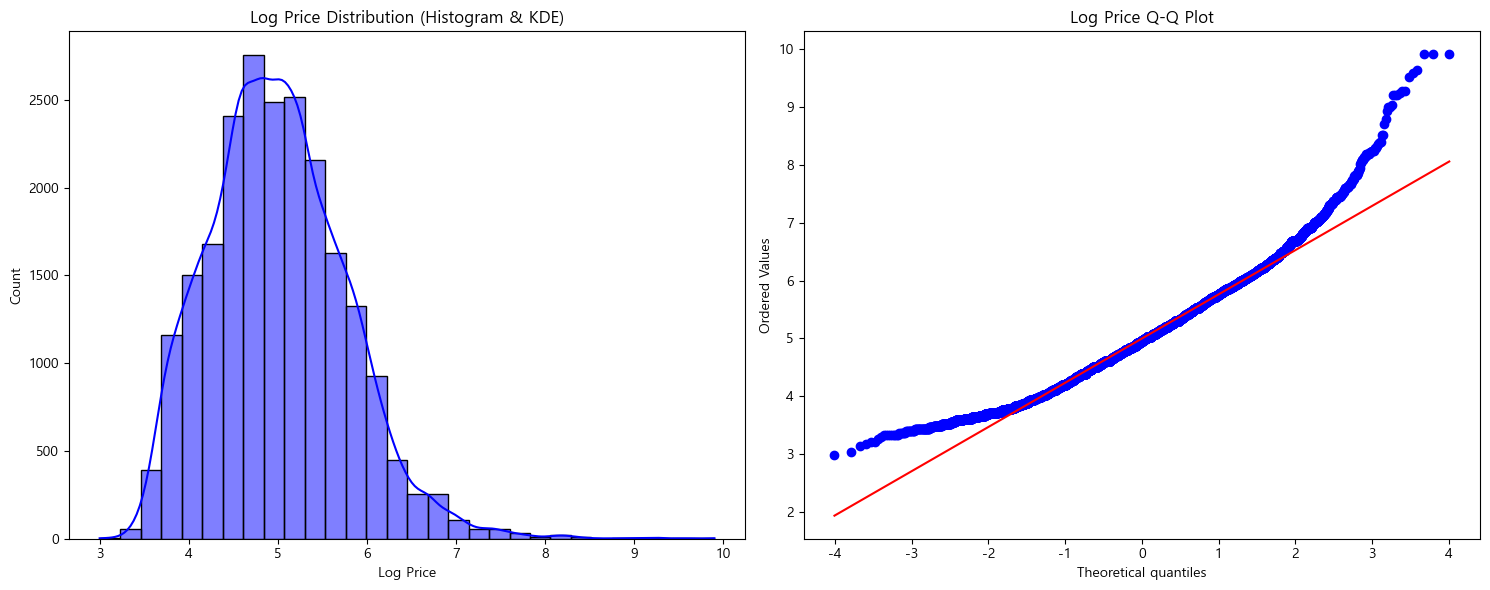

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(clean_df['log_price'], kde=True, color='blue', bins=30, ax=axes[0])
axes[0].set_title('Log Price Distribution (Histogram & KDE)')
axes[0].set_xlabel('Log Price')

stats.probplot(clean_df['log_price'], dist="norm", plot=axes[1])
axes[1].set_title('Log Price Q-Q Plot')

plt.tight_layout()
plt.show()

Entire Home 데이터 개수: 12635
Private Room 데이터 개수: 9178


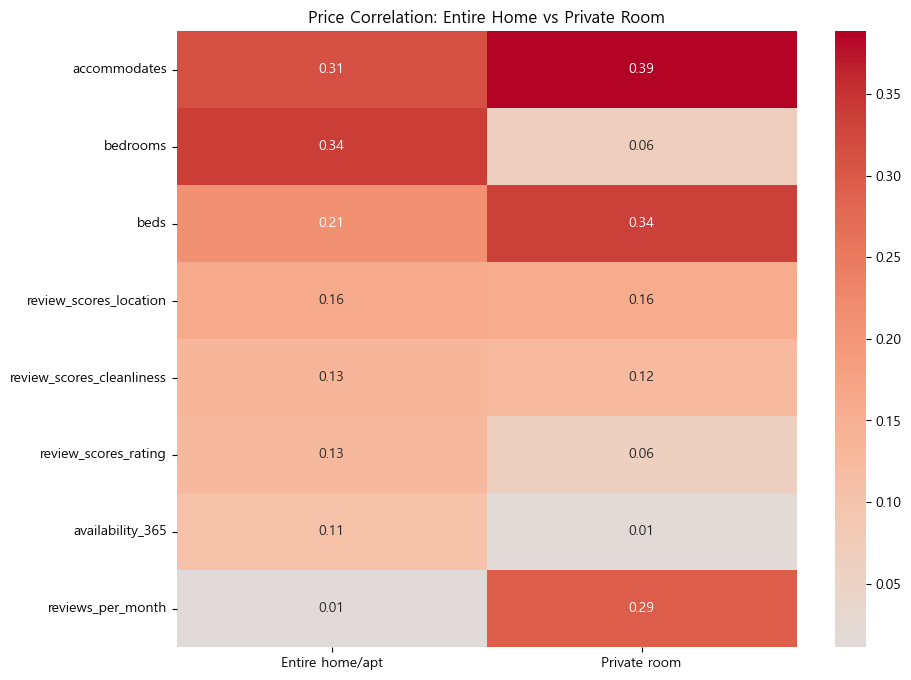

In [27]:
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

private_df = clean_df[clean_df['room_type'] == 'Private room'][target_cols]
entire_df = clean_df[clean_df['room_type'] == 'Entire home/apt'][target_cols]

# 데이터 개수 확인 (신뢰도 체크)
print(f"Entire Home 데이터 개수: {len(entire_df)}")
print(f"Private Room 데이터 개수: {len(private_df)}")

# 3. 그룹별 스피어만 상관계수 계산
private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')

# 4. 결과 합치기
comparison_df = pd.concat([entire_corr, private_corr], axis=1).drop('price') # 'price' 자기 자신은 제외

# 5. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Price Correlation: Entire Home vs Private Room')
plt.show()

In [31]:
import pandas as pd
from scipy import stats

# 데이터 필터링 (Private room vs Entire home/apt)
private_room = df[df['room_type'] == 'Private room']
entire_home = df[df['room_type'] == 'Entire home/apt']

# 수용 인원(accommodates) 데이터 추출
group_p = private_room['accommodates']
group_e = entire_home['accommodates']

In [33]:
# Kolmogorov-Smirnov 검정 (표본이 많을 때 유리)
ks_p = stats.kstest(group_p, 'norm')
ks_e = stats.kstest(group_e, 'norm')

print(f"Private Room 정규성 p-value: {ks_p.pvalue}")
print(f"Entire Home 정규성 p-value: {ks_e.pvalue}")

Private Room 정규성 p-value: 0.0
Entire Home 정규성 p-value: 0.0


In [35]:
# Levene 검정 (중앙값 기준)
levene_test = stats.levene(group_p, group_e, center='median')
print(f"등분산성 p-value: {levene_test.pvalue}")

등분산성 p-value: 0.0


In [37]:
# 정규성 및 등분산성 결과에 따른 자동 선택 예시
is_normal = (ks_p.pvalue > 0.05) and (ks_e.pvalue > 0.05)
is_equal_var = (levene_test.pvalue > 0.05)

if is_normal:
    if is_equal_var:
        # 1. 독립표본 t-검정
        result = stats.ttest_ind(group_p, group_e)
        print("Student's t-test 수행:", result)
    else:
        # 2. Welch's t-test
        result = stats.ttest_ind(group_p, group_e, equal_var=False)
        print("Welch's t-test 수행:", result)
else:
    # 3. Mann-Whitney U test (비모수 검정)
    result = stats.mannwhitneyu(group_p, group_e, alternative='two-sided')
    print("Mann-Whitney U test 수행:", result)

Mann-Whitney U test 수행: MannwhitneyuResult(statistic=np.float64(23067773.0), pvalue=np.float64(0.0))


In [39]:
from scipy import stats

# 두 집단 설정 (예시 변수명)
group_p = df[df['room_type'] == 'Private room']['accommodates']
group_e = df[df['room_type'] == 'Entire home/apt']['accommodates']

# 맨-휘트니 U 검정 수행
u_stat, p_val = stats.mannwhitneyu(group_p, group_e, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"p-value: {p_val}")

if p_val < 0.05:
    print("결론: 두 숙소 유형 간 수용 인원(accommodates)은 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 두 숙소 유형 간 수용 인원의 차이가 통계적으로 유의미하지 않습니다.")

Mann-Whitney U statistic: 23067773.0
p-value: 0.0
결론: 두 숙소 유형 간 수용 인원(accommodates)은 통계적으로 유의미한 차이가 있습니다.


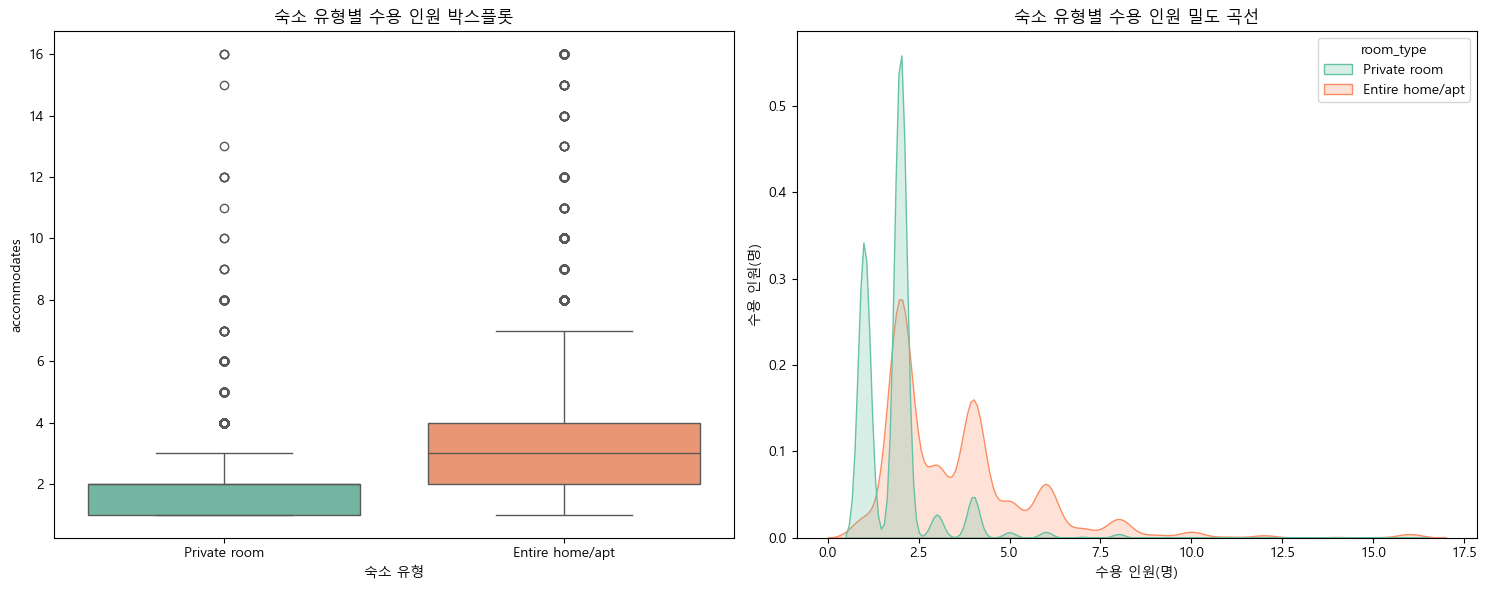

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 시각화를 위한 필터링 데이터 준비
plot_data = df[df['room_type'].isin(['Private room', 'Entire home/apt'])]

# 시각화 영역 설정 (2개의 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot: 중앙값과 이상치 확인
sns.boxplot(x='room_type', y='accommodates', data=plot_data, ax=axes[0], palette='Set2')
axes[0].set_title('숙소 유형별 수용 인원 박스플롯')
axes[0].set_xlabel('숙소 유형')
axes[1].set_ylabel('수용 인원(명)')

# 2. KDE Plot: 분포의 밀도 확인
sns.kdeplot(data=plot_data, x='accommodates', hue='room_type', fill=True, ax=axes[1], palette='Set2')
axes[1].set_title('숙소 유형별 수용 인원 밀도 곡선')
axes[1].set_xlabel('수용 인원(명)')

plt.tight_layout()
plt.show()

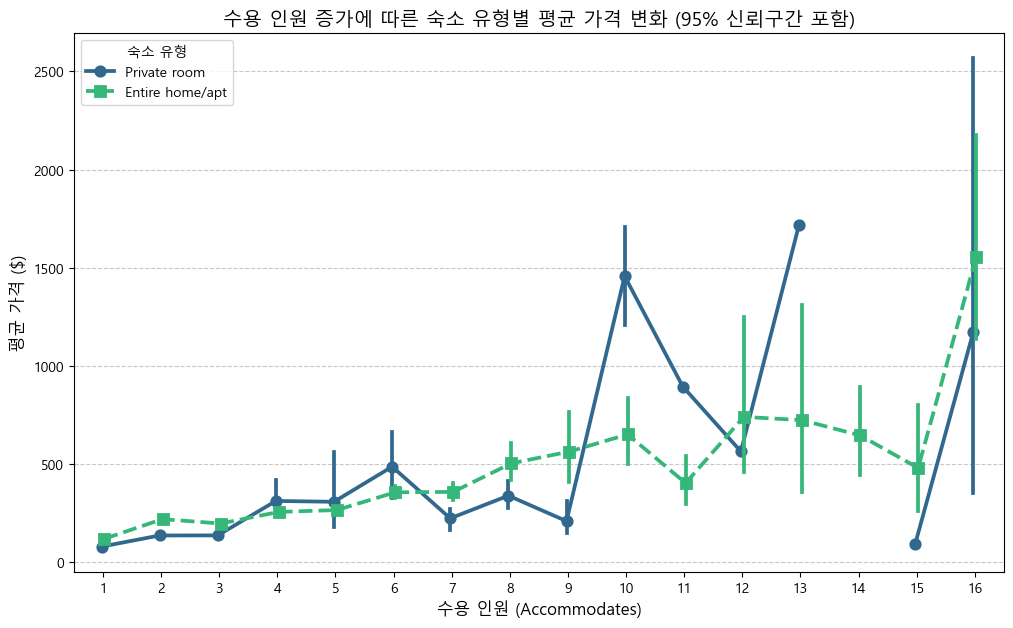

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비 (가독성을 위해 수용 인원 1~6명까지만 제한해서 보는 것이 좋습니다)
plot_df = df[df['room_type'].isin(['Private room', 'Entire home/apt'])]
plot_df = plot_df[plot_df['accommodates'] <= 16]

plt.figure(figsize=(12, 7))

# 포인트 플롯 생성
sns.pointplot(data=plot_df, x='accommodates', y='price', hue='room_type', 
              dodge=True, markers=['o', 's'], linestyles=['-', '--'], palette='viridis')

plt.title('수용 인원 증가에 따른 숙소 유형별 평균 가격 변화 (95% 신뢰구간 포함)', fontsize=14)
plt.xlabel('수용 인원 (Accommodates)', fontsize=12)
plt.ylabel('평균 가격 ($)', fontsize=12)
plt.legend(title='숙소 유형')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()